<a href="https://colab.research.google.com/github/Sneya9205/ckd-progression-prediction/blob/main/Review2_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
os.listdir('/content/drive/MyDrive/sem8')


['hosp_data_analysis.ipynb',
 'converting_zip_to_csv.ipynb',
 'lab_items.ipynb',
 'creatinine_patients.csv',
 'lab_events.ipynb',
 'feature_enginerring.ipynb',
 'efgr_slope.csv',
 'filtered_df.csv',
 'models',
 'ML']

In [ ]:
path='/content/drive/MyDrive/sem8'
df=pd.read_csv(path+"/filtered_df.csv")
df.head(2)


,Unnamed: 0,avg_value,chartdate,subject_id,gender_int,age,egfr
0,0,1.2,2131-11-10,10001843,0,73,84.140397
1,1,1.3,2134-12-05,10001843,0,73,82.532859


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LSTM
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df['chartdate'] = pd.to_datetime(df['chartdate'])

df = df.sort_values(["subject_id", "chartdate"])

df['time_years'] = (
    df.groupby('subject_id')['chartdate']
      .transform(lambda x: (x - x.iloc[0]).dt.days / 365.25)
)


In [ ]:
g = df.groupby("subject_id")

stats = g.agg(
    n_visits = ("egfr", "count"),
    first_date = ("chartdate", "min"),
    last_date  = ("chartdate", "max"),
    missing = ("avg_value", lambda x: x.isna().mean())
).reset_index()


In [ ]:
stats["span_days"] = (
    stats["last_date"] - stats["first_date"]
).dt.days


In [ ]:
def max_gap(x):
    d = x.sort_values()
    return d.diff().dt.days.max()

gap = (
    df.groupby("subject_id")["chartdate"]
      .apply(max_gap)
      .reset_index(name="max_gap")
)

stats = stats.merge(gap, on="subject_id")


In [ ]:
MIN_VISITS = 6
MIN_SPAN   = 180
MAX_GAP    = 365
MAX_MISS   = 0.50
good_ids = stats[
    (stats.n_visits >= MIN_VISITS) &
    (stats.span_days >= MIN_SPAN) &
    (stats.max_gap <= MAX_GAP) &
    (stats.missing <= MAX_MISS)
]["subject_id"]
df_clean = df[df.subject_id.isin(good_ids)].copy()


In [ ]:
def has_aki(pdf):

    egfr = pdf["egfr"].values

    for i in range(1, len(egfr)):
        if abs(egfr[i] - egfr[i-1]) > 30:
            return True

    return False


In [ ]:
MAX_VISITS = 50

df_clean = (
    df_clean
    .groupby("subject_id", sort=False)
    .head(MAX_VISITS)
    .reset_index(drop=True)
)


In [ ]:
bad_aki = (
    df_clean.groupby("subject_id")
    .filter(has_aki)["subject_id"]
    .unique()
)

df_clean = df_clean[~df_clean.subject_id.isin(bad_aki)]


NEW SAMPLING

In [ ]:
def patient_decline(pdf):
    egfr = pdf["egfr"].values

    if len(egfr) < 2:
        return 0

    slope = np.polyfit(range(len(egfr)), egfr, 1)[0]

    return int(slope < -3)

In [ ]:
decline_labels = (
    df_clean
    .groupby("subject_id")
    .apply(patient_decline)
    .reset_index(name="rapid_decline")
)

/tmp/ipykernel_508/3825043205.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(patient_decline)


In [ ]:
df_clean = df_clean.merge(decline_labels, on="subject_id")

In [ ]:


def patient_decline(pdf):

    egfr = pdf["egfr"].values
    time = pdf["time_years"].values

    if len(egfr) < 2:
        return 0

    slope = np.polyfit(time, egfr, 1)[0]

    return int(slope < -3)   # ml/min/year decline


decline_labels = (
    df_clean
    .groupby("subject_id", group_keys=False)
    .apply(patient_decline)
    .reset_index(name="rapid_decline")
)

df_clean = df_clean.merge(decline_labels, on="subject_id")



print("Patients:", df_clean["subject_id"].nunique())


Patients: 23792


/tmp/ipykernel_508/1938388834.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(patient_decline)


In [ ]:

print(
    df_clean
    .groupby("subject_id")["rapid_decline"]
    .first()
    .value_counts(normalize=True)
)

rapid_decline
0    0.746764
1    0.253236
Name: proportion, dtype: float64


In [ ]:

MAX_PATIENTS = 25000
TARGET_DECLINE_RATIO = 0.40

labels = (
    df_clean
    .groupby("subject_id")["rapid_decline"]
    .first()
    .reset_index()
)

pos_ids = labels[labels["rapid_decline"] == 1]["subject_id"].values
neg_ids = labels[labels["rapid_decline"] == 0]["subject_id"].values

print("Decline patients:", len(pos_ids))
print("Stable patients:", len(neg_ids))

np.random.seed(42)

total_available = len(labels)
n_total = min(MAX_PATIENTS, total_available)

n_pos = int(n_total * TARGET_DECLINE_RATIO)
n_neg = n_total - n_pos

n_pos = min(n_pos, len(pos_ids))
n_neg = min(n_neg, len(neg_ids))

sampled_pos = np.random.choice(pos_ids, n_pos, replace=False)
sampled_neg = np.random.choice(neg_ids, n_neg, replace=False)

sampled_ids = np.concatenate([sampled_pos, sampled_neg])

df_final = df_clean[df_clean.subject_id.isin(sampled_ids)].copy()

df_final = df_final.sort_values(["subject_id", "chartdate"]).reset_index(drop=True)

print("\nAfter sampling distribution:")
print(
    df_final.groupby("subject_id")["rapid_decline"]
    .first()
    .value_counts(normalize=True)
)

print("Final patients:", df_final["subject_id"].nunique())

Decline patients: 6025
Stable patients: 17767

After sampling distribution:
rapid_decline
0    0.703217
1    0.296783
Name: proportion, dtype: float64
Final patients: 20301


In [ ]:
#break

In [ ]:
'''MAX_PATIENTS = 100000

pos_ids = decline_labels[
    decline_labels.rapid_decline == 1
]["subject_id"].values

neg_ids = decline_labels[
    decline_labels.rapid_decline == 0
]["subject_id"].values

np.random.seed(42)

# choose ratio (example: 40% decline)
pos_n = int(MAX_PATIENTS * 0.4)
neg_n = MAX_PATIENTS - pos_n

sampled_pos = np.random.choice(
    pos_ids,
    min(pos_n, len(pos_ids)),
    replace=False
)

sampled_neg = np.random.choice(
    neg_ids,
    min(neg_n, len(neg_ids)),
    replace=False
)

sampled_ids = np.concatenate([sampled_pos, sampled_neg])

df_final = df_clean[
    df_clean.subject_id.isin(sampled_ids)
]
MAX_PATIENTS = 8000

pids = df_clean["subject_id"].unique()

if len(pids) > MAX_PATIENTS:

    np.random.seed(42)

    sampled = np.random.choice(
        pids,
        MAX_PATIENTS,
        replace=False
    )

    df_final = df_clean[
        df_clean.subject_id.isin(sampled)
    ]

else:
    df_final = df_clean.copy()
'''


In [ ]:
print("Patients:", df_final["subject_id"].nunique())

print(
    df_final.groupby("subject_id")["rapid_decline"]
    .first()
    .value_counts(normalize=True)
)

Patients: 20301
rapid_decline
0    0.703217
1    0.296783
Name: proportion, dtype: float64


In [ ]:
FEATURES = [
    "egfr",
    "avg_value",
    "gender_int",
    "age",
    "time_years"
]
TARGET = 'egfr'


In [ ]:
def fast_temporal_split(df, split_ratio=0.8):
    df = df.sort_values(["subject_id", "chartdate"])

    # rank visits per patient
    df["visit_idx"] = df.groupby("subject_id").cumcount()
    df["n_visits"] = df.groupby("subject_id")["subject_id"].transform("count")

    df["is_train"] = df["visit_idx"] < (df["n_visits"] * split_ratio)

    train_df = df[df["is_train"]].drop(columns=["visit_idx", "n_visits", "is_train"])
    test_df  = df[~df["is_train"]].drop(columns=["visit_idx", "n_visits", "is_train"])

    return train_df, test_df

In [ ]:
def ultra_fast_multistep_sequences(df, window_size=3, horizon=6):
    X_all, y_all, T_all = [], [], []

    values  = df[FEATURES].to_numpy(np.float32)
    targets = df[TARGET].to_numpy(np.float32)
    times   = df["time_years"].to_numpy(np.float32)
    subjects = df["subject_id"].to_numpy()

    boundaries = np.where(subjects[:-1] != subjects[1:])[0] + 1
    splits = np.split(np.arange(len(df)), boundaries)

    for idx in splits:
        n = len(idx)
        if n < window_size + horizon:
            continue

        data   = values[idx]
        target = targets[idx]
        time   = times[idx]

        X = np.lib.stride_tricks.sliding_window_view(
            data, (window_size, data.shape[1])
        )[:, 0, :, :]

        y = np.lib.stride_tricks.sliding_window_view(
            target, horizon
        )[window_size:]

        t = np.lib.stride_tricks.sliding_window_view(
            time, horizon
        )[window_size:]

        X_all.append(X[:len(y)])
        y_all.append(y)
        T_all.append(t)

    return np.vstack(X_all), np.vstack(y_all), np.vstack(T_all)


In [ ]:
def make_test_sequences(train_df, test_df, window_size, horizon):
    X_test, y_test, T_test = [], [], []

    for pid in train_df["subject_id"].unique():
        train_pdf = train_df[train_df["subject_id"] == pid]
        test_pdf  = test_df[test_df["subject_id"] == pid]

        if len(test_pdf) < horizon or len(train_pdf) < window_size:
            continue

        # past inputs
        X = train_pdf[FEATURES].iloc[-window_size:].to_numpy(np.float32)

        # future egfr
        y = test_pdf[TARGET].iloc[:horizon].to_numpy(np.float32)

        # future time (THIS is the missing piece)
        t = test_pdf["time_years"].iloc[:horizon].to_numpy(np.float32)

        X_test.append(X)
        y_test.append(y)
        T_test.append(t)

    return np.stack(X_test), np.stack(y_test), np.stack(T_test)


In [ ]:
def forecasting_split(df, horizon):
    train_parts = []
    test_parts = []

    for pid, pdf in df.groupby("subject_id", sort=False):
        n = len(pdf)
        if n <= horizon:
            continue

        train_parts.append(pdf.iloc[:-horizon])
        test_parts.append(pdf.iloc[-horizon:])

    return (
        pd.concat(train_parts).reset_index(drop=True),
        pd.concat(test_parts).reset_index(drop=True),
    )

'''def horizon_aware_split(df, window_size=3, horizon=6, split_ratio=0.8):
    train_parts = []
    test_parts = []

    for pid, pdf in df.groupby("subject_id", sort=False):
        n = len(pdf)
        min_test = window_size + horizon

        if n <= min_test:
            continue  # skip short patients entirely

        split = max(int(n * split_ratio), n - min_test)

        train_parts.append(pdf.iloc[:split])
        test_parts.append(pdf.iloc[split:])

    return (
        pd.concat(train_parts).reset_index(drop=True),
        pd.concat(test_parts).reset_index(drop=True),
    )'''


'def horizon_aware_split(df, window_size=3, horizon=6, split_ratio=0.8):\n    train_parts = []\n    test_parts = []\n\n    for pid, pdf in df.groupby("subject_id", sort=False):\n        n = len(pdf)\n        min_test = window_size + horizon\n\n        if n <= min_test:\n            continue  # skip short patients entirely\n\n        split = max(int(n * split_ratio), n - min_test)\n\n        train_parts.append(pdf.iloc[:split])\n        test_parts.append(pdf.iloc[split:])\n\n    return (\n        pd.concat(train_parts).reset_index(drop=True),\n        pd.concat(test_parts).reset_index(drop=True),\n    )'

In [ ]:
#train_df, test_df = fast_temporal_split(df_small, split_ratio=0.8)
train_df, test_df = forecasting_split(
    df_final,
    horizon=6
)
fill_vals = {}


for col in FEATURES:
    fill_vals[col] = train_df[col].median()

for col in FEATURES:
    train_df[col] = train_df[col].fillna(fill_vals[col])
    test_df[col]  = test_df[col].fillna(fill_vals[col])

In [ ]:
train_df = train_df.sort_values(["subject_id", "chartdate"]).reset_index(drop=True)
test_df  = test_df.sort_values(["subject_id", "chartdate"]).reset_index(drop=True)


In [ ]:
WINDOW = 30
HORIZON = 6
X_train, y_train,T_train = ultra_fast_multistep_sequences(
    train_df,
    window_size=WINDOW,
    horizon=HORIZON
)
print(T_train.shape)      # (N, HORIZON)
print(T_train[0])

print(y_train[0])


(40144, 6)
[5.984942  6.1163588 7.0034223 7.206023  7.7043123 7.9534564]
[100.06009 107.94997 107.94997  96.92641 100.06009 100.06009]


In [ ]:
X_train.shape

(40144, 30, 5)

In [ ]:

X_test, y_test,T_test = make_test_sequences(
    train_df,
    test_df,
    window_size=WINDOW,
    horizon=HORIZON
)



In [ ]:
print("X_train:", X_train.shape, X_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)

print("Any NaNs in X?", np.isnan(X_train).any())
print("Any NaNs in y?", np.isnan(y_train).any())


X_train: (40144, 30, 5) float32
y_train: (40144, 6) float32
Any NaNs in X? False
Any NaNs in y? False


In [ ]:
mask = ~np.isnan(y_train).any(axis=1)

X_train = X_train[mask]
y_train = y_train[mask]
T_train = T_train[mask]
print("Any NaNs in y?", np.isnan(y_train).any())


Any NaNs in y? False


In [ ]:
print("NaN in X:", np.isnan(X_train).any())
print("Inf in X:", np.isinf(X_train).any())

print("NaN in y:", np.isnan(y_train).any())
print("Inf in y:", np.isinf(y_train).any())


NaN in X: False
Inf in X: False
NaN in y: False
Inf in y: False


In [ ]:
mask = ~np.isinf(y_train).any(axis=1)

X_train = X_train[mask]
y_train = y_train[mask]
T_train = T_train[mask]


In [ ]:
print("NaN in X:", np.isnan(X_train).any())
print("Inf in X:", np.isinf(X_train).any())

print("NaN in y:", np.isnan(y_train).any())
print("Inf in y:", np.isinf(y_train).any())


NaN in X: False
Inf in X: False
NaN in y: False
Inf in y: False


In [ ]:
print("Inf in y after filter:", np.isinf(y_train).any())
print("NaN in y after filter:", np.isnan(y_train).any())


Inf in y after filter: False
NaN in y after filter: False


In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("NaNs in X:", np.isnan(X_train).sum())
print("NaNs in y:", np.isnan(y_train).sum())


X_train shape: (40144, 30, 5)
y_train shape: (40144, 6)
NaNs in X: 0
NaNs in y: 0


In [ ]:

print("NaNs left:", np.isnan(X_train).sum())
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

NaNs left: 0
X_train shape: (40144, 30, 5)
y_train shape: (40144, 6)


In [ ]:
'''# before:
# X_train, y_train, X_test, y_test, T_train, T_test normalized

import numpy as np

np.save(f"{BASE_PATH}/X_train.npy", X_train)
np.save(f"{BASE_PATH}/y_train.npy", y_train)
np.save(f"{BASE_PATH}/T_train.npy", T_train)

np.save(f"{BASE_PATH}/X_test.npy", X_test)
np.save(f"{BASE_PATH}/y_test.npy", y_test)
np.save(f"{BASE_PATH}/T_test.npy", T_test)
'''

'# before:\n# X_train, y_train, X_test, y_test, T_train, T_test normalized\n\nimport numpy as np\n\nnp.save(f"{BASE_PATH}/X_train.npy", X_train)\nnp.save(f"{BASE_PATH}/y_train.npy", y_train)\nnp.save(f"{BASE_PATH}/T_train.npy", T_train)\n\nnp.save(f"{BASE_PATH}/X_test.npy", X_test)\nnp.save(f"{BASE_PATH}/y_test.npy", y_test)\nnp.save(f"{BASE_PATH}/T_test.npy", T_test)\n'

In [ ]:
# normalize X
X_mean = X_train.mean(axis=(0,1), keepdims=True)
X_std  = X_train.std(axis=(0,1), keepdims=True) + 1e-6

X_train_norm = (X_train - X_mean) / X_std
X_test_norm  = (X_test  - X_mean) / X_std   # <-- YOU MISSED THIS
# normalize y
y_train_raw = y_train.copy()
y_test_raw  = y_test.copy()
y_mean = y_train_raw.mean()
y_std  = y_train_raw.std() + 1e-6

y_train_norm = (y_train_raw - y_mean) / y_std
y_test_norm  = (y_test_raw  - y_mean) / y_std



In [ ]:
# After:
# X_train, y_train, X_test, y_test, T_train, T_test normalized
BASE_PATH = "/content/drive/MyDrive/sem8/models/transformer/complex5"

import numpy as np
os.makedirs(BASE_PATH,exist_ok=True)
np.save(f"{BASE_PATH}/X_train_norm.npy", X_train_norm)
np.save(f"{BASE_PATH}/y_train_norm.npy", y_train_norm)

np.save(f"{BASE_PATH}/X_test_norm.npy", X_test_norm)
np.save(f"{BASE_PATH}/y_test_norm.npy", y_test_norm)

np.save(f"{BASE_PATH}/T_train_norm.npy", T_train)

np.save(f"{BASE_PATH}/T_test_norm.npy", T_test)


Cost sensitive learning

In [ ]:
def compute_slope(seq, time):
    return np.polyfit(time, seq, 1)[0]

true_slopes_train = np.array([
    compute_slope(y, t)
    for y, t in zip(y_train_raw, T_train)
])

RAPID_THRESHOLD =  np.percentile(true_slopes_train, 15)
y_train_risk = (true_slopes_train < RAPID_THRESHOLD).astype(int)



In [ ]:
n_pos = np.sum(y_train_risk == 1)
n_neg = np.sum(y_train_risk == 0)

class_weight = {
    0: 1.0,
    1: n_neg / (n_pos + 1e-6)
}

print(class_weight)


{0: 1.0, 1: np.float64(5.666223844957452)}


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop=EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
WINDOW  = 30
HORIZON = 6
F       = len(FEATURES)  # should be 3

# X_train: (N, 3, 3)
# y_train: (N, 6)
# X_test:  (M, 3, 3)
# y_test:  (M, 6)

# ensure float32
X_train = X_train.astype("float32")
y_train = y_train.astype("float32")
X_test  = X_test.astype("float32")
y_test  = y_test.astype("float32")


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Dense, LayerNormalization, Dropout,
    MultiHeadAttention, GlobalMaxPooling1D,
    Input, Conv1D, Embedding
)
from tensorflow.keras.models import Model


def transformer_block(x, embed_dim=64, num_heads=4, ff_dim=128, dropout=0.1):

    attn = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim
    )(x, x)

    attn = Dropout(dropout)(attn)

    x = LayerNormalization()(x + attn)

    ffn = Dense(ff_dim, activation="relu")(x)
    ffn = Dense(embed_dim)(ffn)

    ffn = Dropout(dropout)(ffn)

    x = LayerNormalization()(x + ffn)

    return x


def build_temporal_transformer(timesteps, num_features, horizon):

    inputs = Input(shape=(timesteps, num_features))
    x = Dense(64)(inputs)

    positions = tf.range(start=0, limit=timesteps, delta=1)
    pos_embed = Embedding(input_dim=timesteps, output_dim=64)(positions)

    x = x + pos_embed

    x = Conv1D(
        filters=64,
        kernel_size=3,
        padding="causal",
        activation="relu"
    )(x)

    x = transformer_block(x)
    x = transformer_block(x)
    x = transformer_block(x)

    x = GlobalMaxPooling1D()(x)

    x = Dropout(0.2)(x)
    outputs = Dense(horizon)(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(3e-4),
        loss=tf.keras.losses.Huber(),
        metrics=["mae"]
    )

    return model

In [ ]:

import tensorflow as tf
from tensorflow.keras.layers import Conv1D, Dense, Dropout, GlobalAveragePooling1D, Input
from tensorflow.keras.models import Model
model_tt = build_temporal_transformer(
    timesteps=WINDOW,
    num_features=len(FEATURES),
    horizon=HORIZON
)

model_tt.summary()
model_tt.fit(
    X_train_norm,
    y_train_norm,
    epochs=200,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop],
    shuffle=True
)
'''
model_tt= build_temporal_transformer(
    timesteps=WINDOW,
    num_features=F,
    horizon=HORIZON
)

model_tt.fit(
    X_train_norm,
    y_train_norm,
    epochs=200,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop],
    class_weight=class_weight,
    shuffle=False
)
'''

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30, 64)    │        384 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 64)    │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 30, 64)    │     12,352 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 64)    │     66,368 │ conv1d[0][0],     │
│ (MultiHeadAttentio… │                   │            │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 64)    │          0 │ conv1d[0][0],     │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 30, 64)    │      8,256 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 30, 64)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 30, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 30, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 30, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 64)    │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 30, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 30, 64)    │      8,256 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 30, 64)    │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 262,726 (1.00 MB)

 Trainable params: 262,726 (1.00 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
142/142 ━━━━━━━━━━━━━━━━━━━━ 35s 109ms/step - loss: 0.2801 - mae: 0.6057 - val_loss: 0.2663 - val_mae: 0.6249
Epoch 2/200
142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1547 - mae: 0.4257 - val_loss: 0.2173 - val_mae: 0.5488
Epoch 3/200
142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1168 - mae: 0.3581 - val_loss: 0.1563 - val_mae: 0.4500
Epoch 4/200
142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0991 - mae: 0.3233 - val_loss: 0.1322 - val_mae: 0.4001
Epoch 5/200
142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0921 - mae: 0.3081 - val_loss: 0.1042 - val_mae: 0.3398
Epoch 6/200
142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0887 - mae: 0.3005 - val_loss: 0.1015 - val_mae: 0.3312
Epoch 7/200
142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0866 - mae: 0.2958 - val_loss: 0.0902 - val_mae: 0.3040
Epoch 8/200
142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0843 - mae: 0.2897 - val_loss: 0.0898 - val_mae: 0.2994
Epoch 9/200
142/142 ━━━━━━━━━━━━━━━━━━

'\nmodel_tt= build_temporal_transformer(\n    timesteps=WINDOW,\n    num_features=F,\n    horizon=HORIZON\n)\n\nmodel_tt.fit(\n    X_train_norm,\n    y_train_norm,\n    epochs=200,\n    batch_size=256,\n    validation_split=0.1,\n    callbacks=[early_stop],\n    class_weight=class_weight,\n    shuffle=False\n)\n'

Results Section Order

 Trajectory plot
 Slope scatter
 ROC
 Confusion
 Stage matrix
  Risk histogram

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
def plot_risk_distribution(risk_score, y_true_risk):

    plt.figure(figsize=(7,4))

    plt.hist(
        risk_score[y_true_risk==0],
        bins=30,
        alpha=0.6,
        label="Low Risk"
    )

    plt.hist(
        risk_score[y_true_risk==1],
        bins=30,
        alpha=0.6,
        label="High Risk"
    )

    plt.xlabel("Risk Score")
    plt.ylabel("Count")
    plt.title("Risk Score Distribution")
    plt.legend()
    plt.savefig("risk_dist5.png", dpi=300, bbox_inches="tight")
    plt.show()


# Call
def plot_confusion(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(4,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Low", "High"],
        yticklabels=["Low", "High"]
    )

    plt.xlabel("Predicted Risk")
    plt.ylabel("True Risk")
    plt.title("Risk Confusion Matrix")
    plt.savefig("confusion5.png", dpi=300, bbox_inches="tight")
    plt.show()

from sklearn.metrics import confusion_matrix

def plot_stage_confusion(true_stage, pred_stage):

    cm = confusion_matrix(true_stage, pred_stage)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Greens"
    )

    plt.xlabel("Predicted Stage")
    plt.ylabel("True Stage")
    plt.title("CKD Stage Prediction")
    plt.savefig("stage_confusion5.png", dpi=300, bbox_inches="tight")
    plt.show()




In [ ]:
from sklearn.metrics import roc_curve, auc

def plot_roc(y_true_risk, pred_slopes):

    scores = -pred_slopes   # higher = worse

    fpr, tpr, _ = roc_curve(y_true_risk, scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))

    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], '--', color='gray')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Risk Prediction)")
    plt.legend()
    plt.grid()
    plt.savefig("roc5.png", dpi=300, bbox_inches="tight")
    plt.show()


# Call


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_trajectories(model, X_test, y_test, y_mean, y_std, n=5):

    y_pred = model.predict(X_test) * y_std + y_mean
    y_true = y_test * y_std + y_mean

    idx = np.random.choice(len(y_true), n, replace=False)

    plt.figure(figsize=(10,5))

    for i, k in enumerate(idx):

        plt.plot(
            y_true[k],
            '--o',
            label=f"True {i+1}",
            alpha=0.7
        )

        plt.plot(
            y_pred[k],
            '-o',
            label=f"Pred {i+1}",
            alpha=0.7
        )

    plt.xlabel("Future Visit (Horizon)")
    plt.ylabel("eGFR")
    plt.title("True vs Predicted eGFR Trajectories")
    plt.legend()
    plt.grid()
    plt.savefig("trajectories5.png", dpi=300, bbox_inches="tight")
    plt.show()


# Call


In [ ]:
def plot_slope_scatter(true_slopes, pred_slopes):

    plt.figure(figsize=(6,6))

    plt.scatter(true_slopes, pred_slopes, alpha=0.5)

    lims = [
        min(true_slopes.min(), pred_slopes.min()),
        max(true_slopes.max(), pred_slopes.max())
    ]

    plt.plot(lims, lims, '--', color='black')

    plt.xlabel("True Slope (mL/min/year)")
    plt.ylabel("Predicted Slope")
    plt.title("Slope Prediction Performance")
    plt.grid()
    plt.savefig("plot_slope_scatter5.png", dpi=300, bbox_inches="tight")

    plt.show()




In [ ]:
def egfr_to_stage(e):
    if e >= 90: return 1
    elif e >= 60: return 2
    elif e >= 45: return 3
    elif e >= 30: return 4
    elif e >= 15: return 5
    else: return 6

In [ ]:
from sklearn.metrics import f1_score
def get_thresh(true_risk,pred_slopes):

  best_t = None
  best_f1 = 0

  for t in np.linspace(pred_slopes.min(), pred_slopes.max(), 100):

      pred = (pred_slopes < t).astype(int)
      f1 = f1_score(true_risk, pred)

      if f1 > best_f1:
          best_f1 = f1
          best_t = t

  print("Best threshold:", best_t)
  print("Best F1:", best_f1)
  return best_t

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_cm(cm):
    labels = ["Stable", "Rapid"]

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix – CKD Rapid Progression")

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_cm_percent(cm):

    labels = ["Stable", "Rapid"]

    cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm_percent,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix (%)")

    plt.show()

181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Best threshold: -0.4237934785236348
Best F1: 0.32438926712054467


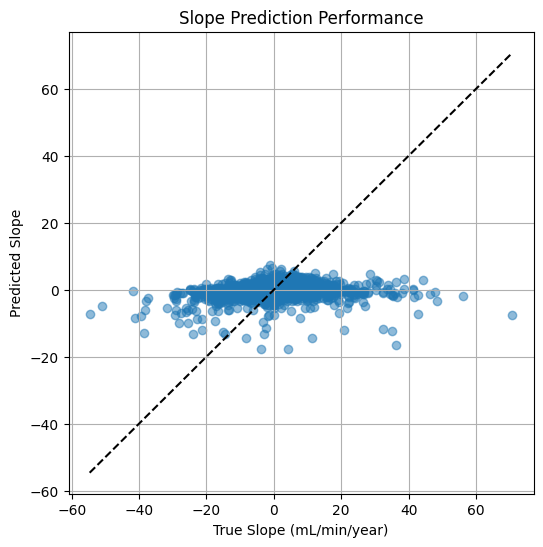

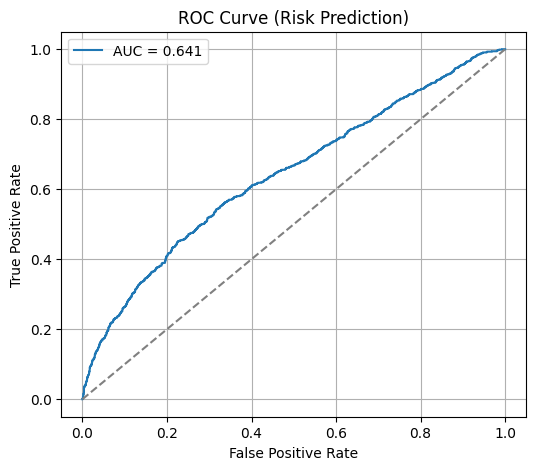

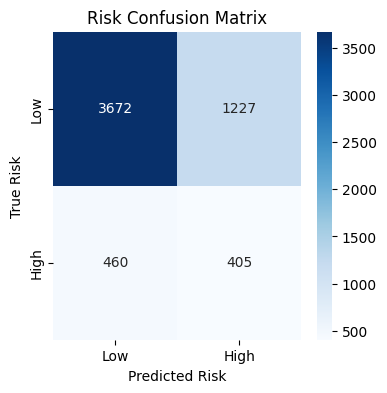

181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


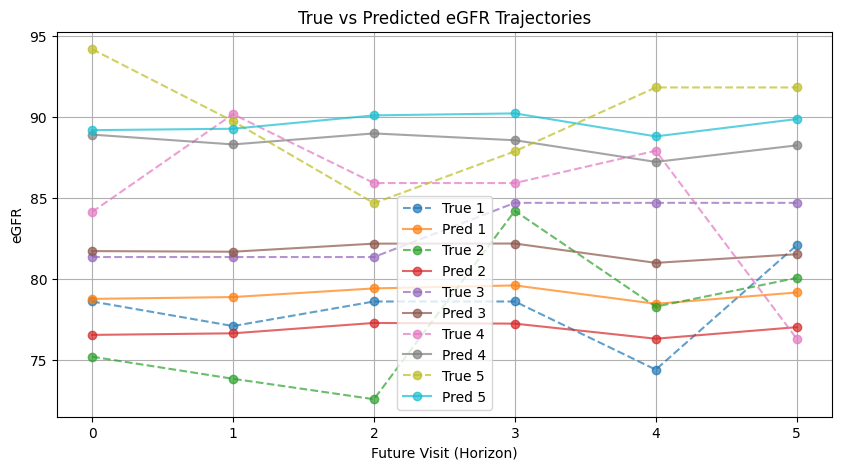

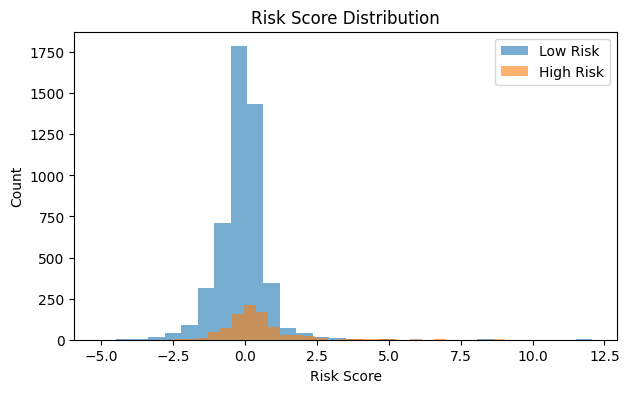

Pred min/max: 36.602146 151.26132
True min/max: 38.192684 193.6663
True mean: 81.91909
{'MAE': np.float32(4.098481), 'RMSE': np.float32(6.4561143), 'RMSE_t+1': np.float32(5.0104885), 'RMSE_t+K': np.float32(7.585888), 'Slope_RMSE': np.float64(7.408220131558811), 'Slope_corr': np.float64(0.15109916499027962), 'AUROC': np.float64(0.6412727854097864), 'Recall': 0.4682080924855491, 'Precision': 0.24816176470588236, 'Confusion_matrix': array([[3672, 1227],
       [ 460,  405]]), 'Model': 'Transformer'}


In [ ]:

from sklearn.metrics import roc_auc_score

import numpy as np
from scipy.special import expit

from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    confusion_matrix
)
y_mean = y_train_raw.mean()
y_std  = y_train_raw.std() + 1e-6
'''def compute_slope(seq,time):
    """
    seq: array of shape (HORIZON,)
    returns: slope
    """
    x = np.arange(len(seq))
    return np.polyfit(time, seq, 1)[0]
'''
def compute_slope(seq, time):

    # convert to relative time (years from first visit)
    t = time - time[0]

    # avoid divide by zero
    if t[-1] <= 0:
        t = np.arange(len(seq))
    else:
        # normalize to [0,1] for stability
        t = t / t[-1]

    return np.polyfit(t, seq, 1)[0]

def evaluate_model(name,model, X_test, y_test, y_mean, y_std, horizon):
    # predict
    y_pred_norm = model.predict(X_test_norm)
    y_pred = y_pred_norm * y_std + y_mean   # real eGFR
    y_true = y_test_raw                    # real eGFR

    # horizon RMSE
    rmse_h1 = np.sqrt(np.mean((y_true[:, 0] - y_pred[:, 0])**2))
    rmse_hk = np.sqrt(np.mean((y_true[:, -1] - y_pred[:, -1])**2))

    # slopes

    # De-normalize
    #y_pred = y_pred_norm * y_std + y_mean
    #y_true = y_test * y_std + y_mean

    # Compute slopes
    pred_slopes = np.array([
        compute_slope(y, t)
        for y, t in zip(y_pred, T_test)
    ])

    true_slopes = np.array([
        compute_slope(y, t)
        for y, t in zip(y_true, T_test)
    ])
    #true_slopes = np.array([compute_slope(y,t) for y in y_true])
    #pred_slopes = np.array([compute_slope(y,t) for y in y_pred])
    # Call

    slope_rmse = np.sqrt(np.mean((true_slopes - pred_slopes)**2))
    slope_corr = (
        np.corrcoef(true_slopes, pred_slopes)[0, 1]
        if np.std(pred_slopes) > 0 else 0.0
    )

    # risk classification
    # bottom 15% = high risk
    true_risk = (true_slopes < np.percentile(true_slopes, 15)).astype(int)

    threshold =get_thresh(true_risk,pred_slopes) #np.percentile(true_slopes, 15)

    y_pred_risk = (pred_slopes < threshold).astype(int)
    y_true_risk = true_risk
    #y_true_risk = (true_slopes < threshold).astype(int)
    #y_pred_risk = (pred_slopes < threshold).astype(int)
    '''
    RAPID_THRESHOLD = -5
    y_true_risk = (true_slopes < RAPID_THRESHOLD).astype(int)
    y_pred_risk = (pred_slopes < RAPID_THRESHOLD).astype(int)

    risk_percentile = 10  # top 10% fastest decline
    threshold = np.percentile(pred_slopes, risk_percentile)
    y_pred_risk = (pred_slopes < threshold).astype(int)
    '''
    plot_slope_scatter(true_slopes, pred_slopes)
    plot_roc(y_true_risk, pred_slopes)
    plot_confusion(y_true_risk, y_pred_risk)
    plot_trajectories(model, X_test_norm, y_test_norm, y_mean, y_std)
    #plot_stage_confusion(true_stage, pred_stage)

    #risk_score = -pred_slopes
    #prob_risk = expit(risk_score)
    risk_score = -pred_slopes
    risk_score = (risk_score - risk_score.mean()) / risk_score.std()
    prob_risk = expit(risk_score)
    plot_risk_distribution(risk_score, y_true_risk)
    mae = tf.keras.metrics.MeanAbsoluteError()
    rmse = tf.keras.metrics.RootMeanSquaredError()

    # Sanity check
    print("Pred min/max:", y_pred.min(), y_pred.max())
    print("True min/max:", y_true.min(), y_true.max())
    print("True mean:", y_true.mean())
    mae.update_state(y_test_raw, y_pred)
    rmse.update_state(y_test_raw, y_pred)
    auc = roc_auc_score(y_true_risk, -pred_slopes)  # negative because lower slope = worse
    precision = precision_score(y_true_risk, y_pred_risk, zero_division=0)
    recall = recall_score(y_true_risk, y_pred_risk, zero_division=0)
    cm = confusion_matrix(y_true_risk, y_pred_risk)

    return {
        "MAE": mae.result().numpy(),
        "RMSE": rmse.result().numpy(),
        "RMSE_t+1": rmse_h1,
        "RMSE_t+K": rmse_hk,
        "Slope_RMSE": slope_rmse,
        "Slope_corr": slope_corr,
        "AUROC": auc,
        "Recall": recall,
        "Precision": precision,
        "Confusion_matrix": cm,
        "Model": name
    }
result_tt=evaluate_model(
        "Transformer",model_tt, X_test, y_test, y_mean, y_std, HORIZON
    )
print(result_tt)


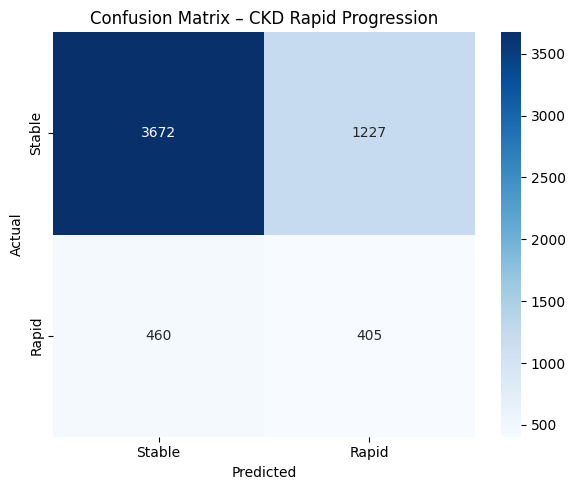

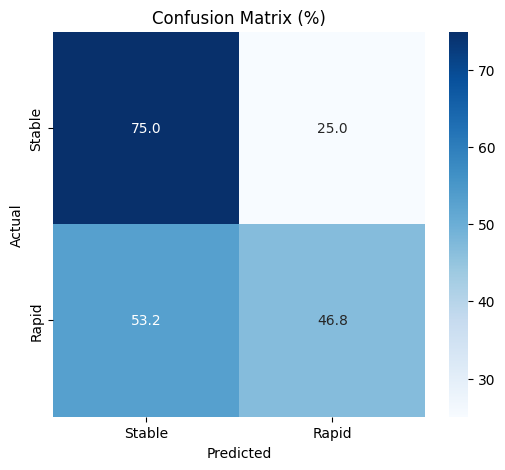

In [ ]:

plot_cm(cm)
plot_cm_percent(cm)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_binary_risk(binary_risk):

    plt.figure(figsize=(5,4))

    sns.countplot(
        x=binary_risk,
        palette=["steelblue","tomato"]
    )

    plt.xticks([0,1], ["Low Risk","High Risk"])
    plt.ylabel("Count")
    plt.title("Binary Risk Prediction Distribution")

    plt.savefig("binary_risk_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Best threshold: -0.4237934785236348
Best F1: 0.32438926712054467


/tmp/ipykernel_508/1596632577.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


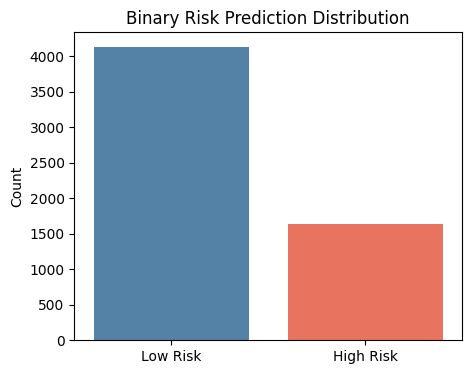

In [ ]:
from scipy.special import expit
y_pred_norm = model_tt.predict(X_test_norm)
y_pred = y_pred_norm * y_std + y_mean
y_true = y_test_raw
pred_slopes = np.array([
        compute_slope(y, t)
        for y, t in zip(y_pred, T_test)
    ])

true_slopes = np.array([
        compute_slope(y, t)
        for y, t in zip(y_true, T_test)
    ])
risk_score = -pred_slopes
prob_risk = expit(risk_score)

true_risk = (true_slopes < np.percentile(true_slopes, 15)).astype(int)

threshold =get_thresh(true_risk,pred_slopes) #np.percentile(true_slopes, 15)

binary_risk = (pred_slopes < threshold).astype(int)
plot_binary_risk(binary_risk)

In [ ]:
from sklearn.metrics import r2_score
last_egfr = X_test[:, -1, 0]  # assuming egfr is feature 0
baseline_pred = np.repeat(last_egfr[:, None], HORIZON, axis=1)

rmse_baseline = np.sqrt(np.mean((y_test_raw - baseline_pred)**2))

print("Baseline RMSE:", rmse_baseline)
r2 = r2_score(true_slopes, pred_slopes)
print("Slope R2:", r2)

Baseline RMSE: 6.9500914
Slope R2: 0.01922474862723278


In [ ]:
def egfr_to_stage(egfr):

    if egfr >= 90: return 1
    if egfr >= 60: return 2
    if egfr >= 30: return 3
    if egfr >= 15: return 4
    return 5


final_egfr = y_pred[:, -1]

pred_stage = np.array([
    egfr_to_stage(x) for x in final_egfr
])

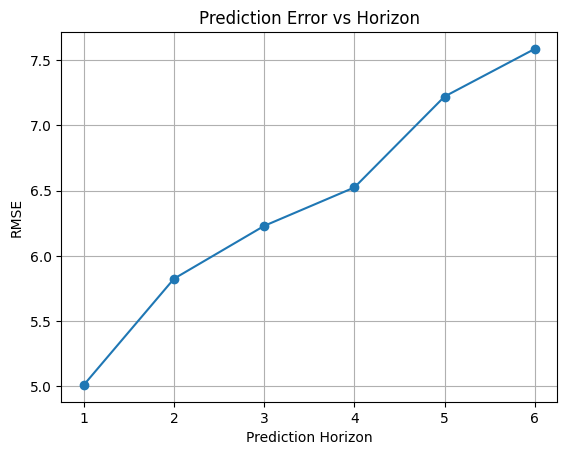

In [ ]:
def plot_horizon_rmse(y_true, y_pred):

    rmses = []

    for h in range(y_true.shape[1]):
        rmse = np.sqrt(np.mean((y_true[:,h] - y_pred[:,h])**2))
        rmses.append(rmse)

    plt.plot(range(1,len(rmses)+1), rmses, marker='o')
    plt.xlabel("Prediction Horizon")
    plt.ylabel("RMSE")
    plt.title("Prediction Error vs Horizon")
    plt.grid()
    plt.show()
plot_horizon_rmse(y_true, y_pred)

In [ ]:
results_df = pd.DataFrame({

    "Patient_ID": test_df["subject_id"].unique()[:len(y_pred)],

    "True_Slope": true_slopes,
    "Pred_Slope": pred_slopes,

    "Continuous_Risk": risk_score,
    "Prob_Risk": prob_risk,
    "Binary_Risk": binary_risk,

    "Final_eGFR": final_egfr,
    "Pred_Stage": pred_stage
})

In [ ]:
results_df.head(20)

,Patient_ID,True_Slope,Pred_Slope,Continuous_Risk,Prob_Risk,Binary_Risk,Final_eGFR,Pred_Stage
0,10000898,3.218701,-0.591353,0.591353,0.643676,1,103.809517,1
1,10001725,0.165172,0.639200,-0.639200,0.345427,0,92.980484,1
2,10001823,-0.652974,0.686977,-0.686977,0.334706,0,69.700394,2
3,10001877,-3.006432,1.107724,-1.107724,0.248295,0,58.933372,3
4,10001919,3.963445,0.820710,-0.820710,0.305613,0,74.146095,2
5,10002013,-0.364956,-0.186787,0.186787,0.546561,0,80.248482,2
6,10002430,-3.893514,0.533952,-0.533952,0.369596,0,79.044273,2
7,10003417,0.241026,0.737979,-0.737979,0.323446,0,75.927734,2
8,10004401,1.639749,0.004386,-0.004386,0.498903,0,85.672554,2
9,10004955,-16.814166,-3.012277,3.012277,0.953126,1,87.700760,2


In [ ]:
print("Pred eGFR min:", final_egfr.min())
print("Pred eGFR max:", final_egfr.max())
print("Pred eGFR mean:", final_egfr.mean())
print("True eGFR min:", y_test_raw[:,-1].min())
print("True eGFR max:", y_test_raw[:,-1].max())
print("True eGFR mean:", y_test_raw[:,-1].mean())
print(len(results_df),results_df["Pred_Stage"].value_counts())

Pred eGFR min: 40.397663
Pred eGFR max: 134.48962
Pred eGFR mean: 81.68479
True eGFR min: 38.192684
True eGFR max: 193.6663
True eGFR mean: 81.90843
5764 Pred_Stage
2    3898
1    1488
3     378
Name: count, dtype: int64


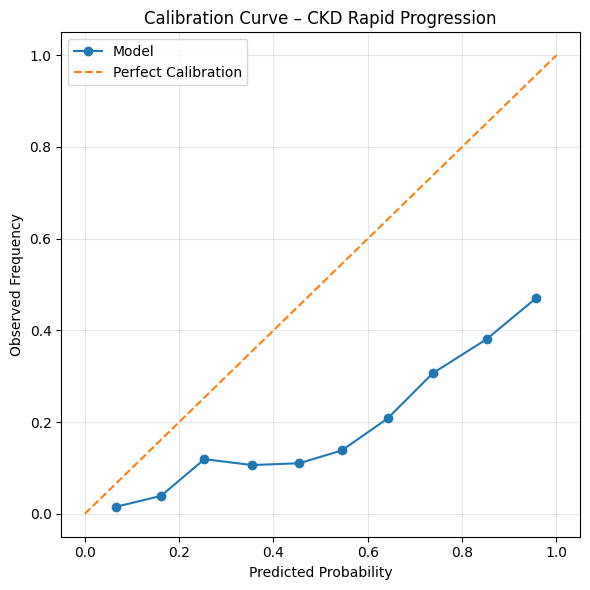

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from scipy.special import expit


pred_slopes = np.array([
    compute_slope(y, t)
    for y, t in zip(y_pred, T_test)
])

true_slopes = np.array([
    compute_slope(y, t)
    for y, t in zip(y_true, T_test)
])

threshold = np.percentile(true_slopes, 15)

y_true_risk = (true_slopes < threshold).astype(int)

risk_score = -pred_slopes
risk_score = (risk_score - risk_score.mean()) / risk_score.std()
prob_risk = expit(risk_score)
y_pred_prob = prob_risk


prob_true, prob_pred = calibration_curve(
    y_true_risk,
    y_pred_prob,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(6,6))

plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0,1],[0,1], linestyle="--", label="Perfect Calibration")

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Curve – CKD Rapid Progression")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

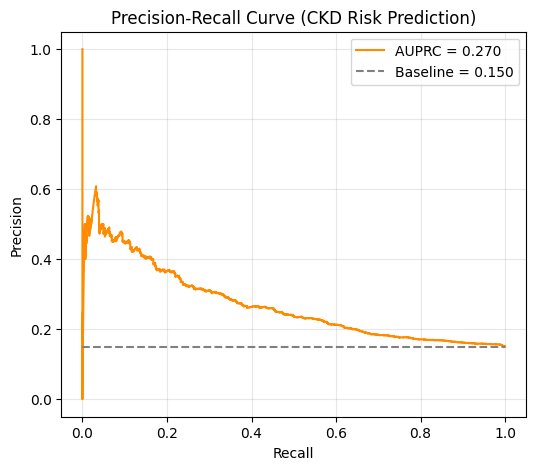

AUPRC: 0.2695917721517766


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_pr_curve(y_true_risk, pred_slopes):

    scores = -pred_slopes   # higher = worse kidney decline

    precision, recall, _ = precision_recall_curve(
        y_true_risk,
        scores
    )

    auprc = average_precision_score(
        y_true_risk,
        scores
    )

    plt.figure(figsize=(6,5))

    plt.plot(
        recall,
        precision,
        label=f"AUPRC = {auprc:.3f}",
        color="darkorange"
    )

    baseline = np.mean(y_true_risk)

    plt.hlines(
        baseline,
        0,
        1,
        linestyle="--",
        color="gray",
        label=f"Baseline = {baseline:.3f}"
    )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve (CKD Risk Prediction)")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.savefig("pr_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("AUPRC:", auprc)
plot_pr_curve(y_true_risk, pred_slopes)

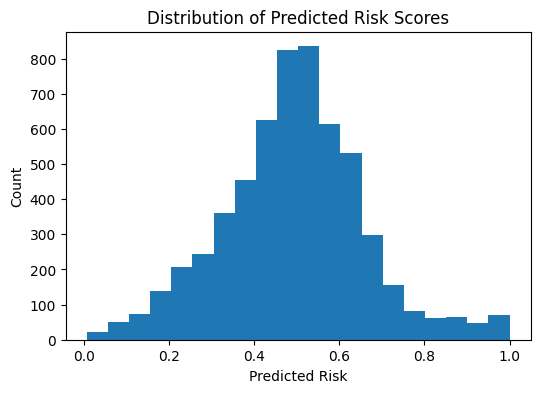

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(y_pred_prob, bins=20)
plt.title("Distribution of Predicted Risk Scores")
plt.xlabel("Predicted Risk")
plt.ylabel("Count")
plt.show()

In [ ]:
import numpy as np
from scipy.special import expit

def display_patient_prediction(patient_idx):

    past_egfr = X_test[patient_idx][:, FEATURES.index("egfr")]

    true_future = y_true[patient_idx]
    pred_future = y_pred[patient_idx]

    times = T_test[patient_idx]

    true_slope = compute_slope(true_future, times)
    pred_slope = compute_slope(pred_future, times)

    risk_score = -pred_slope
    risk_prob = expit(risk_score)

    final_stage = egfr_to_stage(pred_future[-1])

    print("========== PATIENT CKD FORECAST ==========")

    print("\nPast eGFR values (30 visits):")
    print(np.round(past_egfr,2))

    print("\nTrue Future eGFR (6 visits):")
    print(np.round(true_future,2))

    print("\nPredicted Future eGFR:")
    print(np.round(pred_future,2))

    print("\nTrue slope:", round(true_slope,3))
    print("Predicted slope:", round(pred_slope,3))

    print("\nPredicted CKD stage (final visit):", final_stage)

    print("\nRapid progression probability:", round(risk_prob,3))

    if risk_prob > 0.5:
        print("Risk category: HIGH RISK")
    else:
        print("Risk category: LOW RISK")

    print("==========================================")


In [ ]:
display_patient_prediction(10)

========== PATIENT CKD FORECAST ==========

Past eGFR values (30 visits):
[84.67 80.23 81.58 84.67 84.67 83.05 84.67 84.67 84.67 84.67 81.58 83.05
 81.58 84.67 84.67 83.05 83.05 84.67 83.84 80.23 81.58 76.78 82.3  83.05
 84.67 84.67 83.05 81.58 83.05 80.23]

True Future eGFR (6 visits):
[84.67 80.23 83.05 81.58 81.58 81.58]

Predicted Future eGFR:
[80.85 80.82 81.76 81.71 80.66 81.61]

True slope: -1.465
Predicted slope: 0.167

Predicted CKD stage (final visit): 2

Rapid progression probability: 0.458
Risk category: LOW RISK


In [ ]:
display_patient_prediction(110)

========== PATIENT CKD FORECAST ==========

Past eGFR values (30 visits):
[83.57 79.49 83.57 85.19 87.   89.02 87.   89.02 85.19 86.07 85.19 87.
 81.4  81.4  82.09 83.57 80.73 82.09 85.19 89.02 87.   86.07 87.   86.07
 84.36 83.57 85.19 82.09 80.73 80.73]

True Future eGFR (6 visits):
[80.73 76.26 78.33 72.09 76.26 79.49]

Predicted Future eGFR:
[80.57 80.71 81.85 81.8  80.71 81.72]

True slope: -1.782
Predicted slope: 0.818

Predicted CKD stage (final visit): 2

Rapid progression probability: 0.306
Risk category: LOW RISK


In [ ]:
display_patient_prediction(591)

========== PATIENT CKD FORECAST ==========

Past eGFR values (30 visits):
[106.01 106.01 103.35 122.1  103.35 101.   101.    97.02 106.01 103.35
 103.35 106.01 103.35 101.   103.35  97.02 101.   103.35 106.01 106.01
 106.01 101.   106.01 101.   106.01 103.35 102.14 102.14 106.01 106.01]

True Future eGFR (6 visits):
[106.01 122.1  122.1  106.01 122.1  122.1 ]

Predicted Future eGFR:
[105.2  103.41 105.17 105.11 102.47 104.  ]

True slope: 9.196
Predicted slope: -1.269

Predicted CKD stage (final visit): 1

Rapid progression probability: 0.781
Risk category: HIGH RISK


In [ ]:
display_patient_prediction(1890)

========== PATIENT CKD FORECAST ==========

Past eGFR values (30 visits):
[ 99.27 103.35 103.35  99.27 103.35 103.35 103.35 116.54 138.04 124.35
 103.35 103.35 124.35 124.35 124.35 103.35 124.35 124.35 103.35 103.35
 112.96 103.35 103.35 103.35 112.96 103.35  90.79  71.24  72.16  66.93]

True Future eGFR (6 visits):
[68.75 73.13 77.7  80.52 87.83 99.27]

Predicted Future eGFR:
[66.54 68.49 69.63 71.18 71.05 71.16]

True slope: 28.497
Predicted slope: 4.615

Predicted CKD stage (final visit): 2

Rapid progression probability: 0.01
Risk category: LOW RISK


In [ ]:
display_patient_prediction(1344)

========== PATIENT CKD FORECAST ==========

Past eGFR values (30 visits):
[ 81.25  83.13  81.25  79.56  81.25  83.13  81.25  85.27  81.25  85.27
  83.13  83.13  85.27  85.27  98.22 115.29  98.22  98.22  98.22  83.13
  85.27  85.27  85.27  85.27  81.25  83.13  84.17  98.22 115.29  98.22]

True Future eGFR (6 visits):
[81.25 83.13 85.27 85.27 85.27 98.22]

Predicted Future eGFR:
[93.07 91.62 92.27 91.1  89.35 90.05]

True slope: 8.492
Predicted slope: -2.394

Predicted CKD stage (final visit): 1

Rapid progression probability: 0.916
Risk category: HIGH RISK


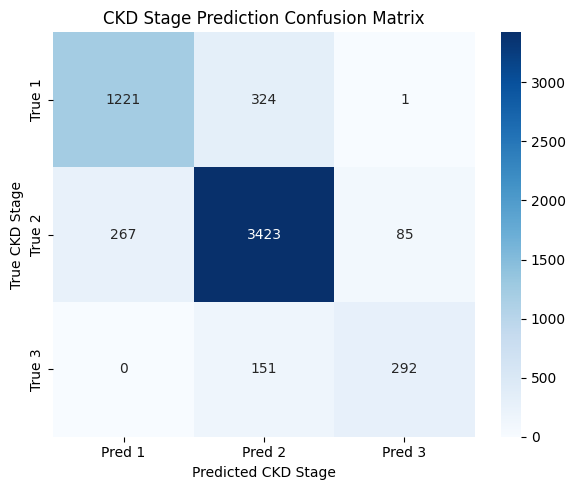

In [ ]:
# True final eGFR
true_final_egfr = y_true[:, -1]

# Predicted final eGFR
pred_final_egfr = y_pred[:, -1]

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


def plot_stage_confusion(true_stage, pred_stage):

    labels = [1, 2, 3]

    cm = confusion_matrix(
        true_stage,
        pred_stage,
        labels=labels
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[f"Pred {l}" for l in labels],
        yticklabels=[f"True {l}" for l in labels]
    )

    plt.xlabel("Predicted CKD Stage")
    plt.ylabel("True CKD Stage")
    plt.title("CKD Stage Prediction Confusion Matrix")

    plt.tight_layout()
    plt.show()
true_stage = np.array([egfr_to_stage(x) for x in true_final_egfr])
pred_stage = np.array([egfr_to_stage(x) for x in pred_final_egfr])
plot_stage_confusion(true_stage, pred_stage)

In [ ]:
stage_rmse = {}

for s in np.unique(true_stage):

    idx = true_stage == s

    rmse = np.sqrt(np.mean(
        (y_true[idx] - y_pred[idx])**2
    ))

    stage_rmse[s] = rmse

print(stage_rmse)

{np.int64(1): np.float32(9.3167305), np.int64(2): np.float32(4.926124), np.int64(3): np.float32(5.7112246)}


In [ ]:
results_df.to_csv("ckd_risk_report4.csv", index=False)
import os
BASE_PATH = "/content/drive/MyDrive/sem8/models/transformer/complex5"
MODEL_NAME = "transformer_ckd_complex5.keras"

os.makedirs(BASE_PATH, exist_ok=True)

model_tt.save(os.path.join(BASE_PATH, MODEL_NAME))



In [ ]:
import pickle

scaler = {
    "X_mean": X_mean,
    "X_std": X_std,
    "y_mean": y_mean,
    "y_std": y_std
}

with open(f"{BASE_PATH}/scaler_complex5.pkl", "wb") as f:
    pickle.dump(scaler, f)




In [ ]:
meta = {
    "WINDOW": WINDOW,
    "HORIZON": HORIZON,
    "FEATURES": FEATURES,
    "MODEL": "Transformer",
    "DATE": "2026-02-19"
}

with open(f"{BASE_PATH}/meta_complex5.pkl", "wb") as f:
    pickle.dump(meta, f)
